In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Column names from the dataset readme
col_names = ['engine_id', 'cycle', 'op1', 'op2', 'op3',
             's1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
             's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']

# Loading the first dataset with 100 engines
train_df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
test_df  = pd.read_csv('test_FD001.txt',  sep='\s+', header=None, names=col_names)
rul_df   = pd.read_csv('RUL_FD001.txt',   sep='\s+', header=None, names=['RUL'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (20631, 26)
Test shape: (13096, 26)
   engine_id  cycle     op1     op2    op3      s1      s2       s3       s4  \
0          1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1          1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2          1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3          1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4          1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  

In [2]:
# Drop constant sensors which are constant or having very low standard deviation
constant_cols = []
for col in [f's{i}' for i in range(1, 22)]:
    if train_df[col].std() < 0.1:
        constant_cols.append(col)

print("Constant sensors (dropping):", constant_cols)

# Also dropping op3 - constant in FD001
drop_cols = constant_cols + ['op3']
train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print("Remaining columns:", train_df.columns.tolist())
print("Shape after dropping:", train_df.shape)

Constant sensors (dropping): ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
Remaining columns: ['engine_id', 'cycle', 'op1', 'op2', 's2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']
Shape after dropping: (20631, 15)


In [3]:
# Computing RUL for training data
# Max cycle for each engine is the total life
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycles, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df = train_df.drop(columns=['max_cycle'])

print(train_df[['engine_id', 'cycle', 'RUL']].head(10))
print("\nMax RUL:", train_df['RUL'].max())
print("Min RUL:", train_df['RUL'].min())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182

Max RUL: 361
Min RUL: 0


After clipping:
Max RUL: 125
Min RUL: 0


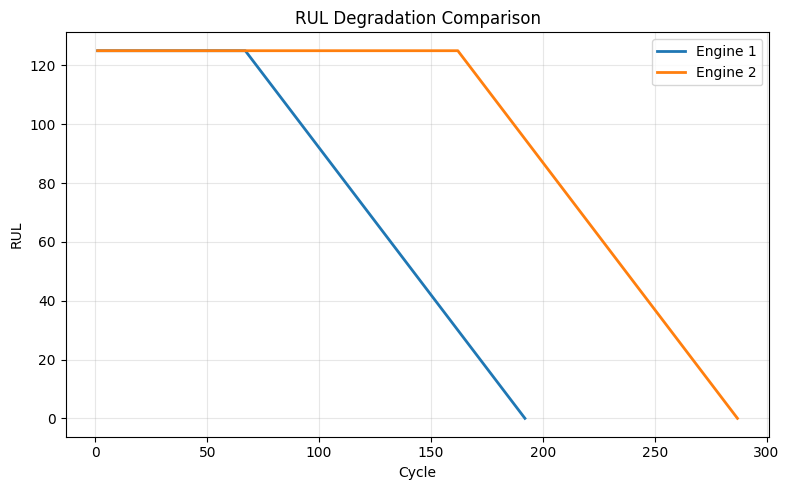

In [4]:
# Clipping RUL at 125 - standard practice for CMAPSS
MAX_RUL = 125
train_df['RUL'] = train_df['RUL'].clip(upper=MAX_RUL)

print("After clipping:")
print("Max RUL:", train_df['RUL'].max())
print("Min RUL:", train_df['RUL'].min())

# Plotting 2 engines to check how the clipping loops with cycles

engine1 = train_df[train_df['engine_id'] == 1]
engine2 = train_df[train_df['engine_id'] == 2]

plt.figure(figsize=(8, 5))

plt.plot(engine1['cycle'], engine1['RUL'], label='Engine 1', linewidth=2)
plt.plot(engine2['cycle'], engine2['RUL'], label='Engine 2', linewidth=2)

plt.title('RUL Degradation Comparison')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rul_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Normalizing each column with min and max values
sensor_cols = [col for col in train_df.columns if col not in ['engine_id', 'cycle', 'RUL']]
print("Sensor columns:", sensor_cols)

scaler = MinMaxScaler()

train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
test_df[sensor_cols] = scaler.transform(test_df[sensor_cols])

print("\nAfter normalization:")
print(train_df[sensor_cols].describe().round(3))

Sensor columns: ['op1', 'op2', 's2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']

After normalization:
             op1        op2         s2         s3         s4         s7  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.499      0.502      0.443      0.425      0.450      0.566   
std        0.126      0.244      0.151      0.134      0.152      0.143   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        0.414      0.333      0.336      0.332      0.339      0.477   
50%        0.500      0.500      0.431      0.416      0.435      0.578   
75%        0.586      0.750      0.539      0.509      0.545      0.670   
max        1.000      1.000      1.000      1.000      1.000      1.000   

              s9        s11        s12        s14        s17        s20  \
count  20631.000  20631.000  20631.000  20631.000  20631.000  20631.000   
mean       0.195      0.411      0.581      0.226

In [6]:
# Creating sliding window sequences (30 cycles) and predicting RUL at the last cycle of each sequence

SEQUENCE_LENGTH = 30

def create_sequences(df, sequence_length):
    sequences = []
    labels = []
    
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].reset_index(drop=True)
        sensor_data = engine_data[sensor_cols].values
        rul_data = engine_data['RUL'].values
        
        for i in range(len(engine_data) - sequence_length + 1):
            sequences.append(sensor_data[i:i+sequence_length])
            labels.append(rul_data[i+sequence_length-1])
    
    return np.array(sequences), np.array(labels)

X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (17731, 30, 13)
y_train shape: (17731,)


In [7]:
# For test, taking only last 30 cycles per engine
def create_test_sequences(df, sequence_length):
    sequences = []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].reset_index(drop=True)
        sensor_data = engine_data[sensor_cols].values

        if len(engine_data) >= sequence_length:
            sequences.append(sensor_data[-sequence_length:])
        else:
            # Padding if engine has fewer than 30 cycles
            pad = np.zeros((sequence_length - len(engine_data), len(sensor_cols)))
            sequences.append(np.vstack([pad, sensor_data]))
    return np.array(sequences)

X_test = create_test_sequences(test_df, SEQUENCE_LENGTH)
y_test = rul_df['RUL'].values

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (100, 30, 13)
y_test shape: (100,)


### Making transformer architecture

In [8]:
import torch
import torch.nn as nn
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class RULTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        
        # Project input sensors to d_model dimensions
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch, sequence_length, input_dim)
        x = self.input_projection(x)   # (batch, seq, d_model)
        x = self.pos_encoding(x)       # add positional info
        x = self.transformer(x)        # (batch, seq, d_model)
        x = x[:, -1, :]                # take last timestep (batch, d_model)
        x = self.regressor(x)          # (batch, 1)
        return x.squeeze(-1)           # (batch,)

# Initializing model
INPUT_DIM = X_train.shape[2]  # 13 sensors
model = RULTransformer(input_dim=INPUT_DIM).to(device)

# Checking the model architecture
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 152,961
RULTransformer(
  (input_projection): Linear(in_features=13, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1):

In [9]:
from torch.utils.data import TensorDataset, DataLoader

# Converting to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training loop
EPOCHS = 50
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | RMSE: {avg_loss**0.5:.4f}")

Epoch 10/50 | Loss: 241.2577 | RMSE: 15.5325
Epoch 20/50 | Loss: 220.5440 | RMSE: 14.8507
Epoch 30/50 | Loss: 185.3881 | RMSE: 13.6157
Epoch 40/50 | Loss: 168.5298 | RMSE: 12.9819
Epoch 50/50 | Loss: 153.0975 | RMSE: 12.3733


In [10]:
import numpy as np

# Evaluation

model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).cpu().numpy()
    
y_test_np = y_test_t.cpu().numpy()

# Metrics
rmse = np.sqrt(np.mean((test_preds - y_test_np)**2))
mae  = np.mean(np.abs(test_preds - y_test_np))

print(f"Transformer RMSE: {rmse:.4f}")
print(f"Transformer MAE:  {mae:.4f}")

Transformer RMSE: 16.7285
Transformer MAE:  12.7097


### LSTM for comparision

In [11]:
class RUL_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]  # take last timestep
        return self.regressor(x).squeeze(-1)

# Initializing
lstm_model = RUL_LSTM(input_dim=INPUT_DIM).to(device)
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM parameters: {lstm_params:,}")

# Training
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_scheduler = torch.optim.lr_scheduler.StepLR(lstm_optimizer, step_size=20, gamma=0.5)
lstm_losses = []

for epoch in range(50):
    lstm_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        lstm_optimizer.zero_grad()
        predictions = lstm_model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        lstm_optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    lstm_losses.append(avg_loss)
    lstm_scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {avg_loss:.4f} | RMSE: {avg_loss**0.5:.4f}")

LSTM parameters: 55,617
Epoch 10/50 | Loss: 302.1929 | RMSE: 17.3837
Epoch 20/50 | Loss: 268.8312 | RMSE: 16.3961
Epoch 30/50 | Loss: 255.0726 | RMSE: 15.9710
Epoch 40/50 | Loss: 249.8825 | RMSE: 15.8077
Epoch 50/50 | Loss: 245.8533 | RMSE: 15.6797


In [12]:
# Evaluation

lstm_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(X_test_t).cpu().numpy()

lstm_rmse = np.sqrt(np.mean((lstm_preds - y_test_np)**2))
lstm_mae = np.mean(np.abs(lstm_preds - y_test_np))

print(f"LSTM Test RMSE: {lstm_rmse:.4f}")
print(f"LSTM Test MAE:  {lstm_mae:.4f}")

# Compare
print(f"\n------------- Model Comparison -------------")
print(f"{'Model':<15} {'RMSE':<10} {'MAE':<10} {'Params':<12}")
print(f"{'Transformer':<15} {rmse:<10.4f} {mae:<10.4f} {total_params:<12,}")
print(f"{'LSTM':<15} {lstm_rmse:<10.4f} {lstm_mae:<10.4f} {lstm_params:<12,}")

LSTM Test RMSE: 15.8986
LSTM Test MAE:  11.9209

------------- Model Comparison -------------
Model           RMSE       MAE        Params      
Transformer     16.7285    12.7097    152,961     
LSTM            15.8986    11.9209    55,617      


### Results and plots

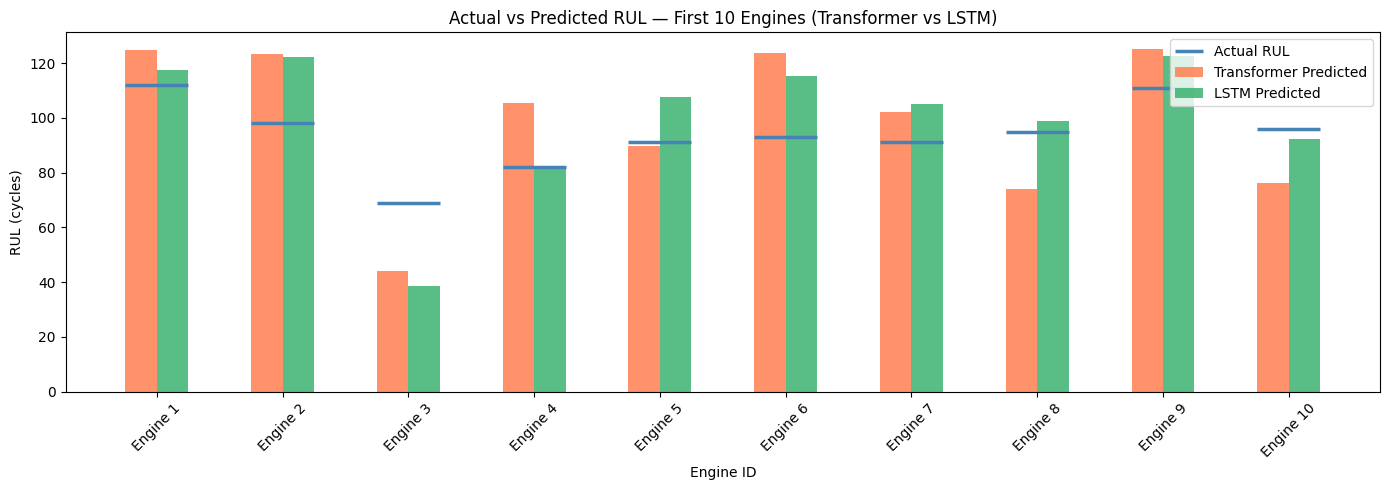

In [ ]:
plt.figure(figsize=(14, 5))
engines = range(10)
x = np.arange(10)
width = 0.25

plt.bar(x - width/2, test_preds[:10], width, label='Transformer Predicted', color='coral', alpha=0.85)
plt.bar(x + width/2, lstm_preds[:10], width, label='LSTM Predicted', color='mediumseagreen', alpha=0.85)

# Actual as a horizontal line marker per engine
for i in x:
    plt.hlines(y_test_np[i], i - width, i + width, 
               colors='steelblue', linewidths=2.5, zorder=5)

plt.hlines([], [], [], colors='steelblue', linewidths=2.5, label='Actual RUL')

plt.xlabel('Engine ID')
plt.ylabel('RUL (cycles)')
plt.title('Actual vs Predicted RUL — First 10 Engines (Transformer vs LSTM)')
plt.xticks(x, [f'Engine {i+1}' for i in engines], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('engine_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

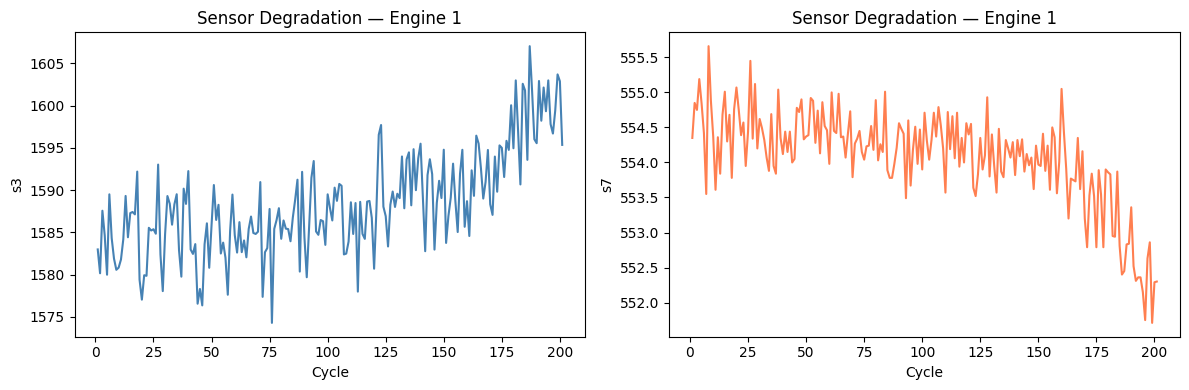

In [14]:
# Sensor degradation over time for engine 1
engine1_raw = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
engine1_raw = engine1_raw[engine1_raw['engine_id'] == 9]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(engine1_raw['cycle'], engine1_raw['s3'], color='steelblue')
plt.xlabel('Cycle')
plt.ylabel('s3')
plt.title('Sensor Degradation — Engine 1')

plt.subplot(1, 2, 2)
plt.plot(engine1_raw['cycle'], engine1_raw['s7'], color='coral')
plt.xlabel('Cycle')
plt.ylabel('s7')
plt.title('Sensor Degradation — Engine 1')

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

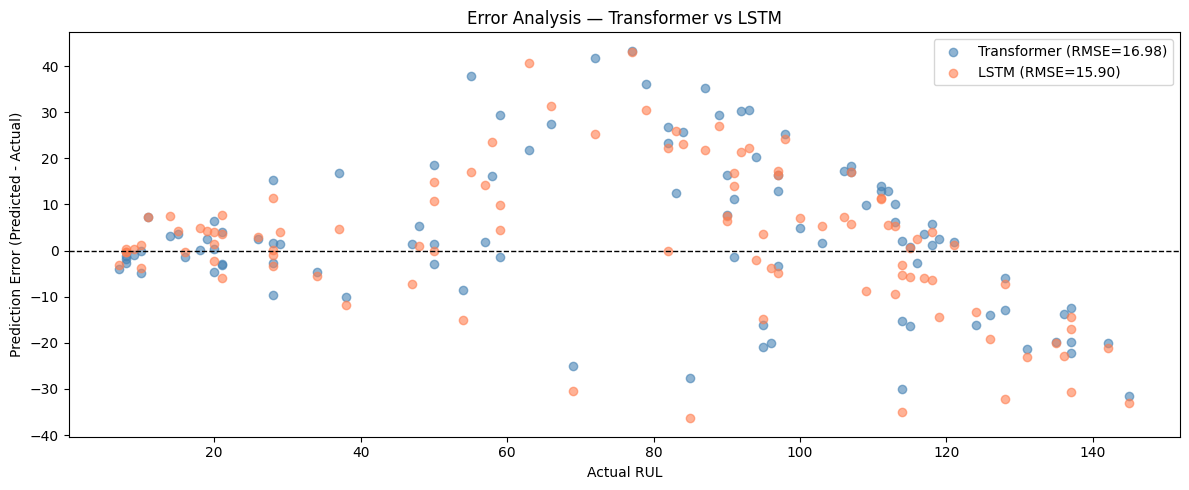

In [17]:
transformer_errors = test_preds - y_test_np
lstm_errors = lstm_preds - y_test_np

plt.figure(figsize=(12, 5))

plt.scatter(y_test_np, transformer_errors, alpha=0.6, color='steelblue', label=f'Transformer (RMSE={16.9785:.2f})')
plt.scatter(y_test_np, lstm_errors, alpha=0.6, color='coral', label=f'LSTM (RMSE={lstm_rmse:.2f})')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Actual RUL')
plt.ylabel('Prediction Error (Predicted - Actual)')
plt.title('Error Analysis — Transformer vs LSTM')
plt.legend()
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def get_attention_weights(model, x_input):
    model.eval()
    attention_weights = []
    
    with torch.no_grad():
        # Step 1: input projection + positional encoding
        x = model.input_projection(x_input)
        x = model.pos_encoding(x)
        
        # Step 2: pass through each transformer layer manually
        for layer in model.transformer.layers:
            # Extract attention weights explicitly
            attn_output, attn_weight = layer.self_attn(
                x, x, x,
                need_weights=True,
                average_attn_weights=True
            )
            attention_weights.append(attn_weight.cpu())
            
            # Continue rest of the layer manually
            x = x + layer.dropout1(attn_output)
            x = layer.norm1(x)
            x2 = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
            x = x + layer.dropout2(x2)
            x = layer.norm2(x)
    return attention_weights

low_rul_idx  = np.argmin(y_test_np)
high_rul_idx = np.argmax(y_test_np)

low_input  = X_test_t[low_rul_idx].unsqueeze(0)
high_input = X_test_t[high_rul_idx].unsqueeze(0)

low_attn  = get_attention_weights(model, low_input)
high_attn = get_attention_weights(model, high_input)

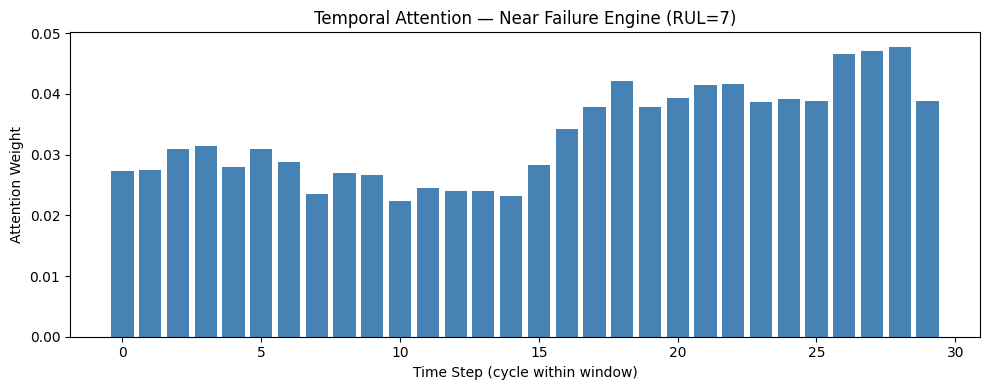

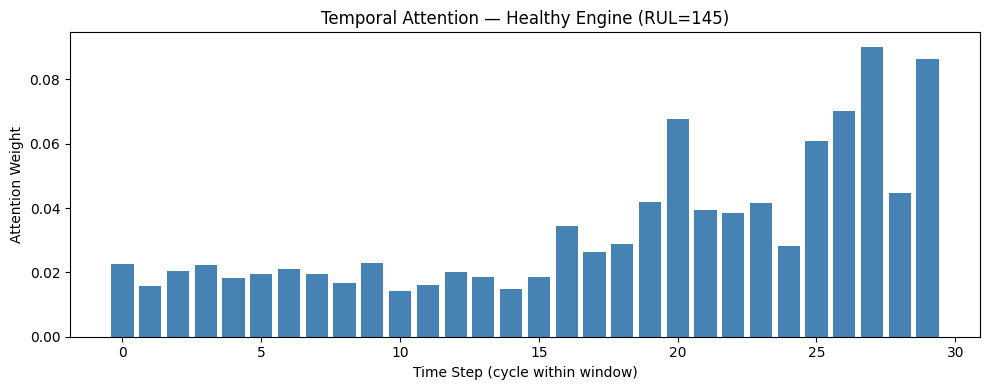

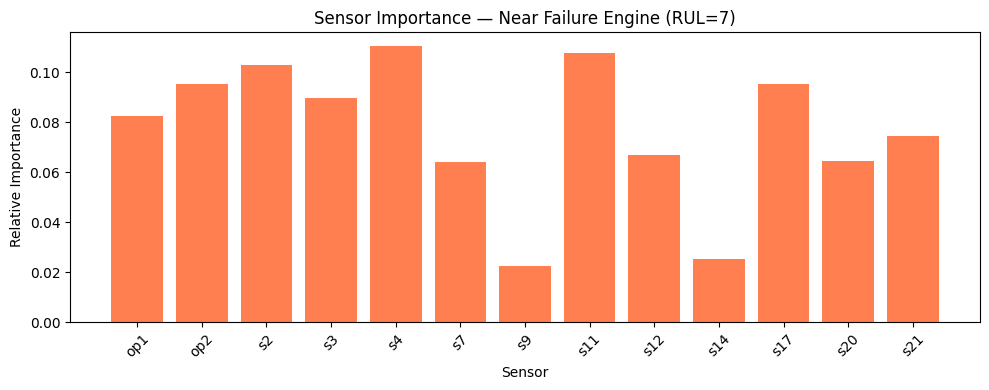

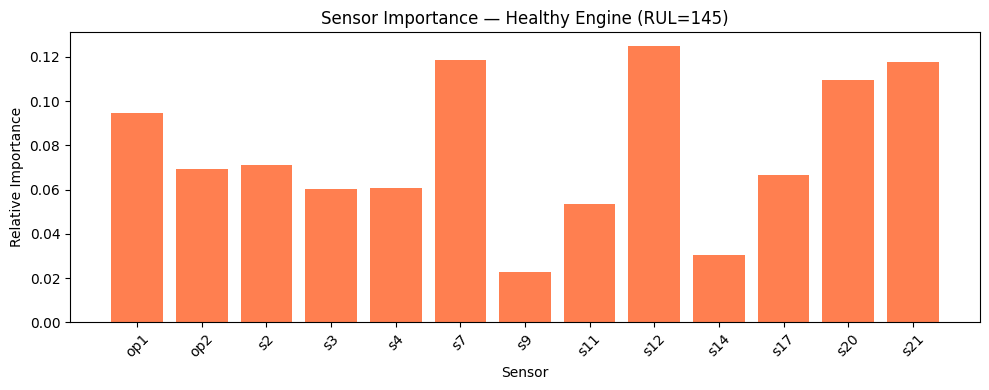

In [22]:
def plot_sensor_attention(attn_weights, title, save_name):
    # attn shape per layer: (1, 30, 30) — already averaged across heads
    all_layers = torch.stack(attn_weights)  # (num_layers, 1, 30, 30)
    avg_attn = all_layers.mean(dim=[0, 1])  # (30, 30)
    
    # Last timestep's attention
    last_timestep_attn = avg_attn[-1, :]  # (30,)
    last_timestep_attn = last_timestep_attn / last_timestep_attn.sum()
    
    plt.figure(figsize=(10, 4))
    plt.bar(range(30), last_timestep_attn.numpy(), color='steelblue')
    plt.xlabel('Time Step (cycle within window)')
    plt.ylabel('Attention Weight')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

def plot_sensor_importance(x_input, attn_weights, title, save_name):
    all_layers = torch.stack(attn_weights)
    avg_attn = all_layers.mean(dim=[0, 1])  # (30, 30)
    
    x = x_input.squeeze(0).cpu().numpy()  # (30, 13)
    attn = avg_attn.numpy()  # (30, 30)
    
    weighted = np.abs(attn @ x)  # (30, 13)
    sensor_importance = weighted.mean(axis=0)
    sensor_importance = sensor_importance / sensor_importance.sum()
    
    plt.figure(figsize=(10, 4))
    plt.bar(sensor_cols, sensor_importance, color='coral')
    plt.xlabel('Sensor')
    plt.ylabel('Relative Importance')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

# Plot all 4
plot_sensor_attention(low_attn,
    f'Temporal Attention — Near Failure Engine (RUL={y_test_np[low_rul_idx]:.0f})',
    'attn_temporal_low_rul.png')

plot_sensor_attention(high_attn,
    f'Temporal Attention — Healthy Engine (RUL={y_test_np[high_rul_idx]:.0f})',
    'attn_temporal_high_rul.png')

plot_sensor_importance(low_input, low_attn,
    f'Sensor Importance — Near Failure Engine (RUL={y_test_np[low_rul_idx]:.0f})',
    'attn_sensor_low_rul.png')

plot_sensor_importance(high_input, high_attn,
    f'Sensor Importance — Healthy Engine (RUL={y_test_np[high_rul_idx]:.0f})',
    'attn_sensor_high_rul.png')